Canal 1: Total esantioane pe disc = 1252700


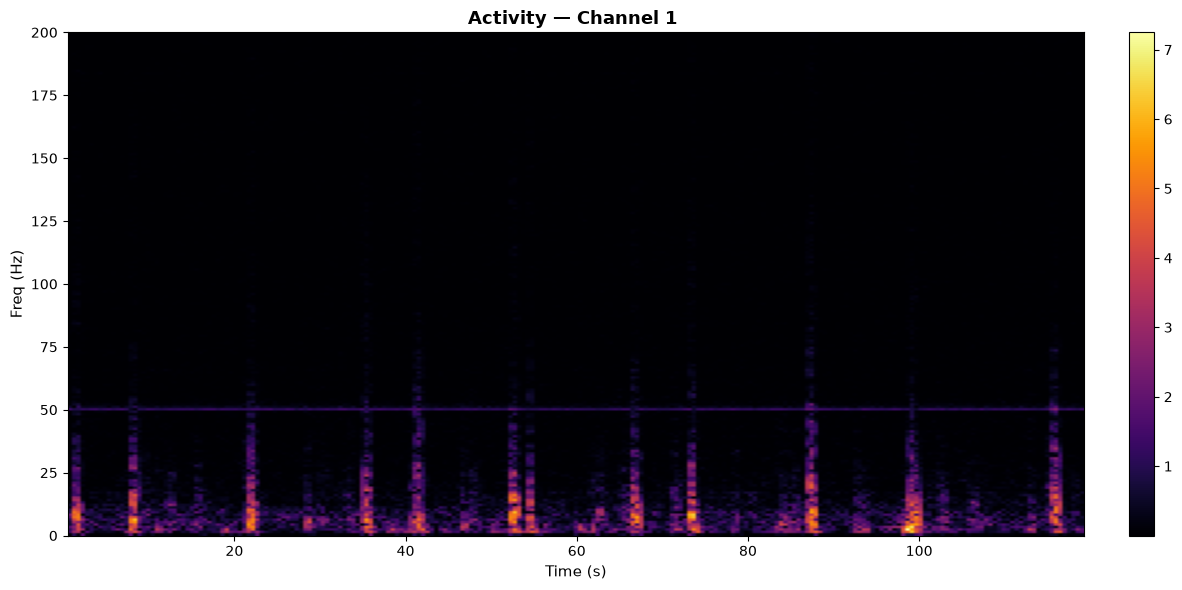

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram
import os

SAMPLE_RATE = 1000
DURATION_SEC = 120
SAMPLES_2_MIN = DURATION_SEC * SAMPLE_RATE 

dataset_path = "Anestezie/M014_S001_SRCS3L_25,50,100_0002" 
bin_files = sorted([f for f in os.listdir(dataset_path) if f.endswith(".bin") and "-Ch" in f])

channels_to_plot = [1]
trial_idx = 0 

plt.figure(figsize=(12, 6))
for i, ch in enumerate(channels_to_plot):
    ax = plt.subplot(len(channels_to_plot), 1, i + 1)
    
    file_path = os.path.join(dataset_path, bin_files[ch])
    ch_data = np.memmap(file_path, dtype=np.float32, mode='r')
    
    total_samples = len(ch_data)
    print(f"Canal {ch}: Total esantioane pe disc = {total_samples}")

    end_idx = min(SAMPLES_2_MIN, total_samples)
    
    filtered_signal = ch_data[0:end_idx]

    #nperseg=1024 (Number of Points per Segment)
    #noverlap=512 (Overlap)
    f, t_axis, Sxx = spectrogram(filtered_signal, fs=SAMPLE_RATE, nperseg=1024, noverlap=512)

    
    Sxx_log = np.log1p(Sxx)
    
    img = ax.imshow(Sxx_log, aspect='auto', origin='lower', 
                    extent=[t_axis[0], t_axis[-1], f[0], f[-1]], cmap='inferno')
    
    ax.set_ylim(0, 200) 
    
    ax.set_title(f"Activity — Channel {ch} ", fontsize=13, fontweight='bold')
    ax.set_ylabel("Freq (Hz)", fontsize=11)
    ax.tick_params(axis='both', which='major', labelsize=10)
    
    cbar = plt.colorbar(img, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=10)

ax.set_xlabel("Time (s)", fontsize=11)
plt.tight_layout()
plt.savefig("Fig3_Spontaneous_2Min.png", format='png', dpi=300)
plt.show()

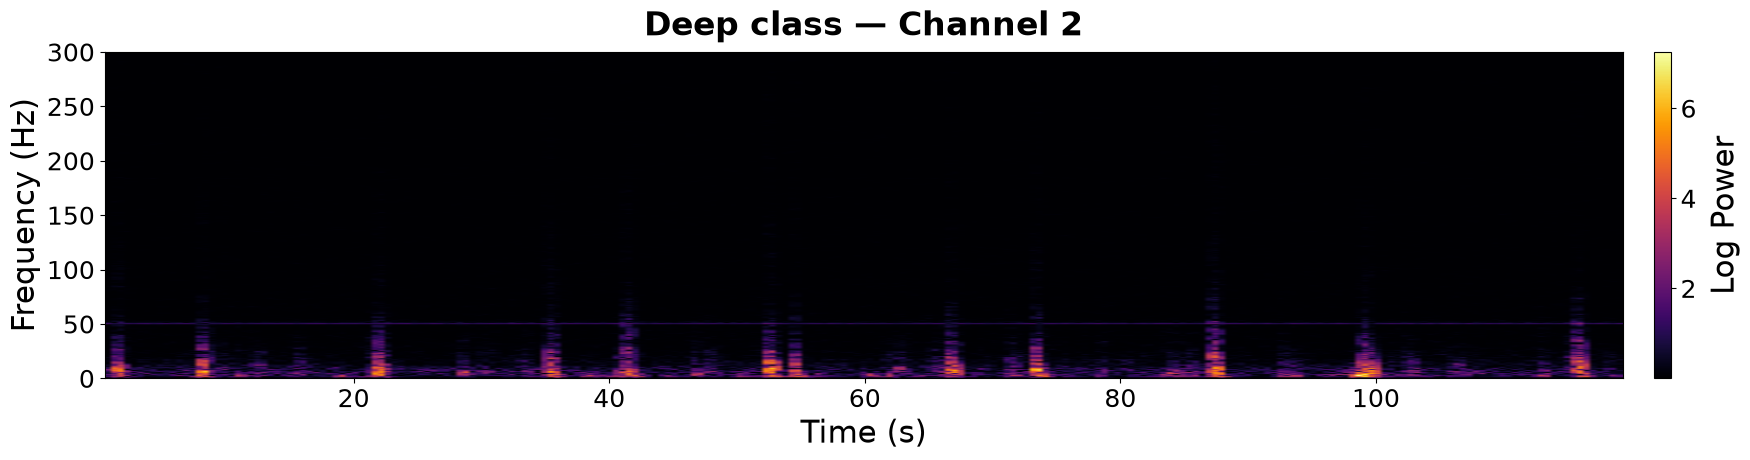

In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram

# Setări globale de font mărite considerabil
plt.rcParams.update({
    'font.size': 20,
    'axes.titlesize': 24,
    'axes.labelsize': 22,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 18,
    'figure.titlesize': 26
})

SAMPLE_RATE = 1000
DURATION_SEC = 120
SAMPLES_2_MIN = DURATION_SEC * SAMPLE_RATE 
MAX_FREQ = 300  # limita spectrului vizibil

dataset_path = "Anestezie/M014_S001_SRCS3L_25,50,100_0002" 
all_files = [f for f in os.listdir(dataset_path) if f.endswith(".bin") and "-Ch" in f]

# Mapare numerica a fisierelor pentru a selecta exact canalul dorit
channel_files = {}
for f in all_files:
    try:
        ch_num = int(f.split("-Ch")[1].split(".")[0])
        channel_files[ch_num] = f
    except (IndexError, ValueError):
        continue

# Canalele pe care vrei sa le compari
channels_to_plot = [2]
num_channels = len(channels_to_plot)

# Inaltime adaptata dinamic pentru vizibilitate optima
plt.figure(figsize=(18, 5.0 * num_channels))

for i, ch in enumerate(channels_to_plot):
    ax = plt.subplot(num_channels, 1, i + 1)
    
    if ch not in channel_files:
        print(f"Canalul {ch} nu a fost gasit.")
        ax.set_visible(False)
        continue

    file_path = os.path.join(dataset_path, channel_files[ch])
    ch_data = np.memmap(file_path, dtype=np.float32, mode='r')
    
    end_idx = min(SAMPLES_2_MIN, len(ch_data))
    filtered_signal = ch_data[:end_idx]

    f, t_axis, Sxx = spectrogram(filtered_signal, fs=SAMPLE_RATE, nperseg=1024, noverlap=512)
    Sxx_log = np.log1p(Sxx)
    
    img = ax.imshow(
        Sxx_log, 
        aspect='auto', 
        origin='lower', 
        extent=[t_axis[0], t_axis[-1], f[0], f[-1]], 
        cmap='inferno'
    )
    
    ax.set_ylim(0, MAX_FREQ) 
    ax.set_title(f"Deep class — Channel {ch}", fontweight='bold', pad=12)
    ax.set_ylabel("Frequency (Hz)")
    
    cbar = plt.colorbar(img, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label("Log Power", labelpad=10)
    
    if i == num_channels - 1:
        ax.set_xlabel("Time (s)")

plt.tight_layout()
plt.savefig("Fig_Canale_Inferno_150Hz.png", format='png', dpi=300)
plt.show()

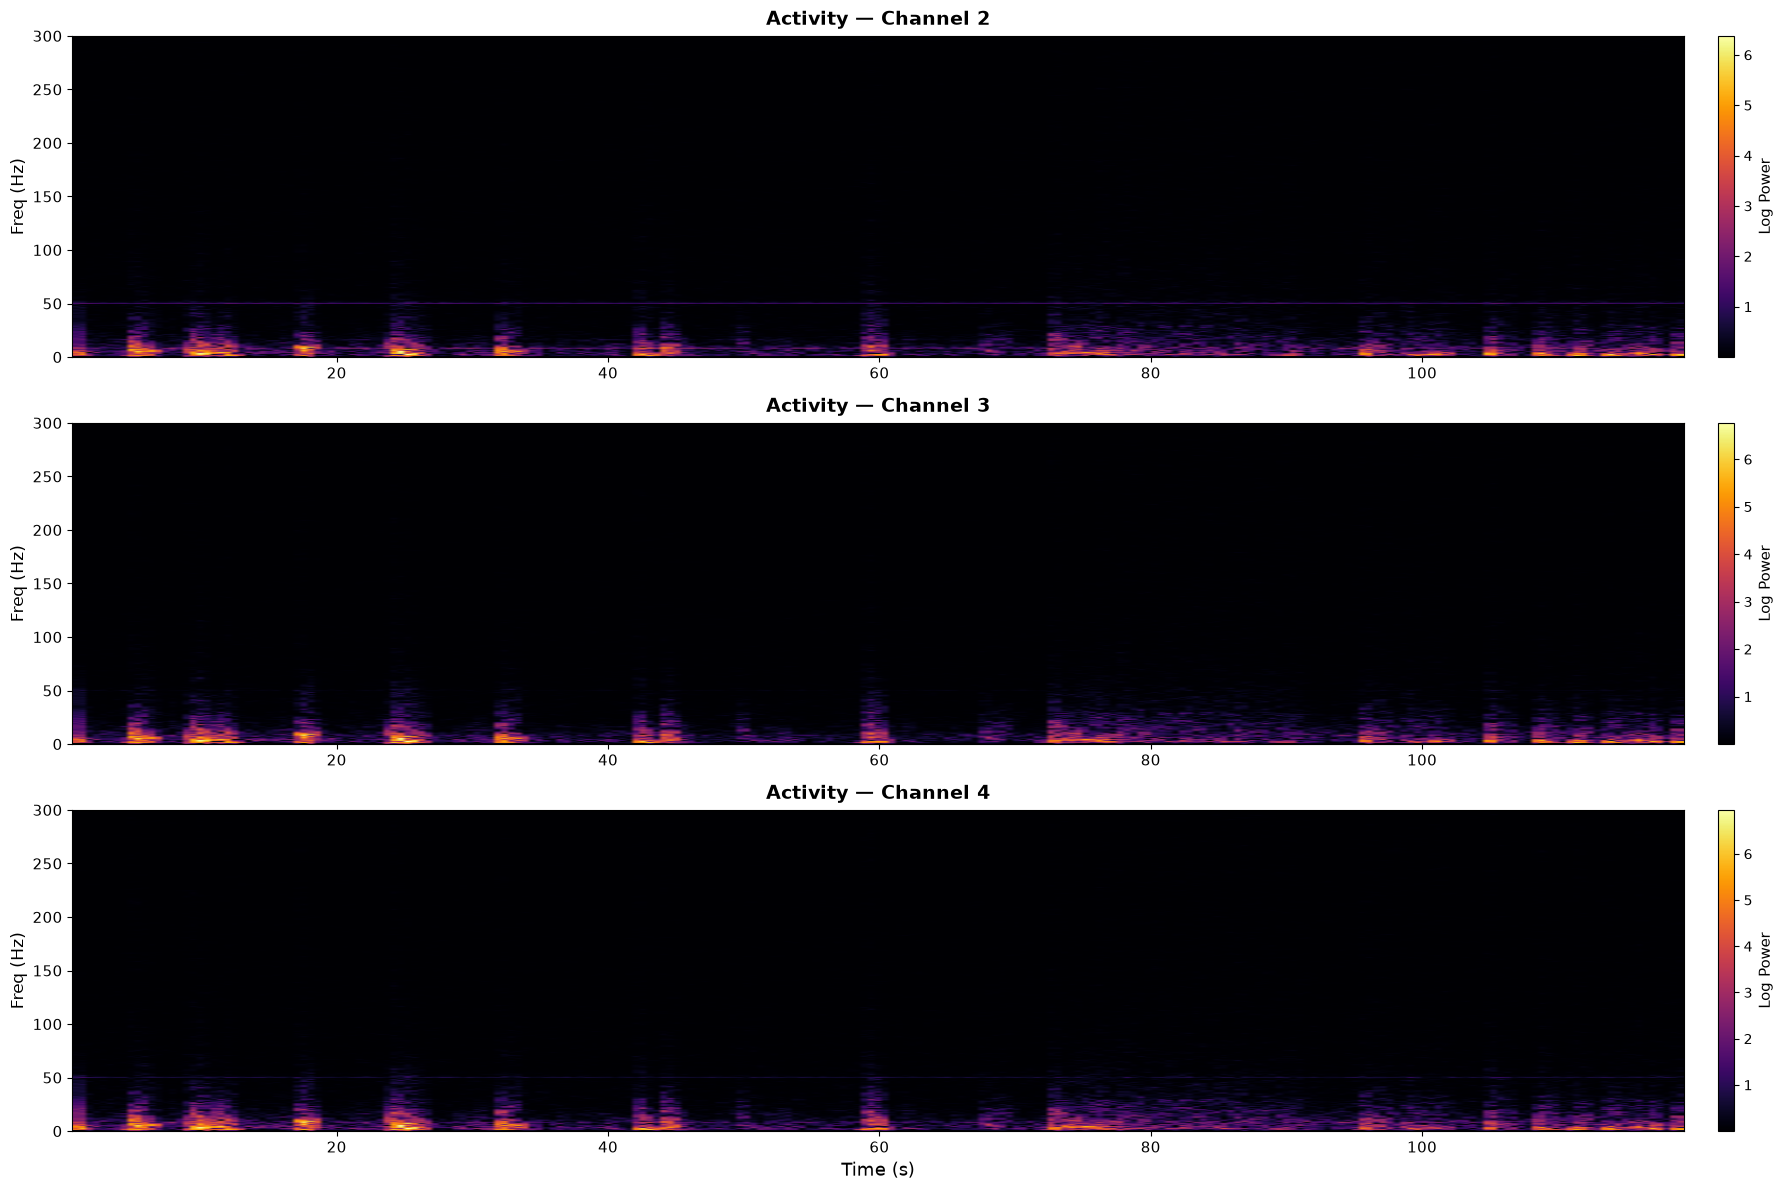

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram

SAMPLE_RATE = 1000
DURATION_SEC = 120
SAMPLES_2_MIN = DURATION_SEC * SAMPLE_RATE 
MAX_FREQ = 300  # limita spectrului vizibil

dataset_path = "Anestezie/M014_S001_SRCS3L_25,50,100_0003" 
all_files = [f for f in os.listdir(dataset_path) if f.endswith(".bin") and "-Ch" in f]

# Mapare numerica a fisierelor pentru a selecta exact canalul dorit
channel_files = {}
for f in all_files:
    try:
        ch_num = int(f.split("-Ch")[1].split(".")[0])
        channel_files[ch_num] = f
    except (IndexError, ValueError):
        continue

# Canalele pe care vrei sa le compari
channels_to_plot = [2, 3, 4]
num_channels = len(channels_to_plot)

# Inaltime adaptata dinamic: 4 unitati per canal pentru vizibilitate optima
plt.figure(figsize=(18, 4 * num_channels))

for i, ch in enumerate(channels_to_plot):
    ax = plt.subplot(num_channels, 1, i + 1)
    
    if ch not in channel_files:
        print(f"⚠️ Canalul {ch} nu a fost gasit.")
        ax.set_visible(False)
        continue

    file_path = os.path.join(dataset_path, channel_files[ch])
    ch_data = np.memmap(file_path, dtype=np.float32, mode='r')
    
    end_idx = min(SAMPLES_2_MIN, len(ch_data))
    filtered_signal = ch_data[:end_idx]

    f, t_axis, Sxx = spectrogram(filtered_signal, fs=SAMPLE_RATE, nperseg=1024, noverlap=512)
    Sxx_log = np.log1p(Sxx)
    
    img = ax.imshow(
        Sxx_log, 
        aspect='auto', 
        origin='lower', 
        extent=[t_axis[0], t_axis[-1], f[0], f[-1]], 
        cmap='inferno'
    )
    
    ax.set_ylim(0, MAX_FREQ) 
    ax.set_title(f"Activity — Channel {ch}", fontsize=14, fontweight='bold', pad=8)
    ax.set_ylabel("Freq (Hz)", fontsize=12)
    ax.tick_params(axis='both', which='major', labelsize=11)
    
    cbar = plt.colorbar(img, ax=ax, fraction=0.03, pad=0.02)
    cbar.ax.tick_params(labelsize=10)
    cbar.set_label("Log Power", fontsize=11)
    
    if i == num_channels - 1:
        ax.set_xlabel("Time (s)", fontsize=13)

plt.tight_layout()
plt.savefig("Fig_Canale_Inferno_150Hz.png", format='png', dpi=300)
plt.show()

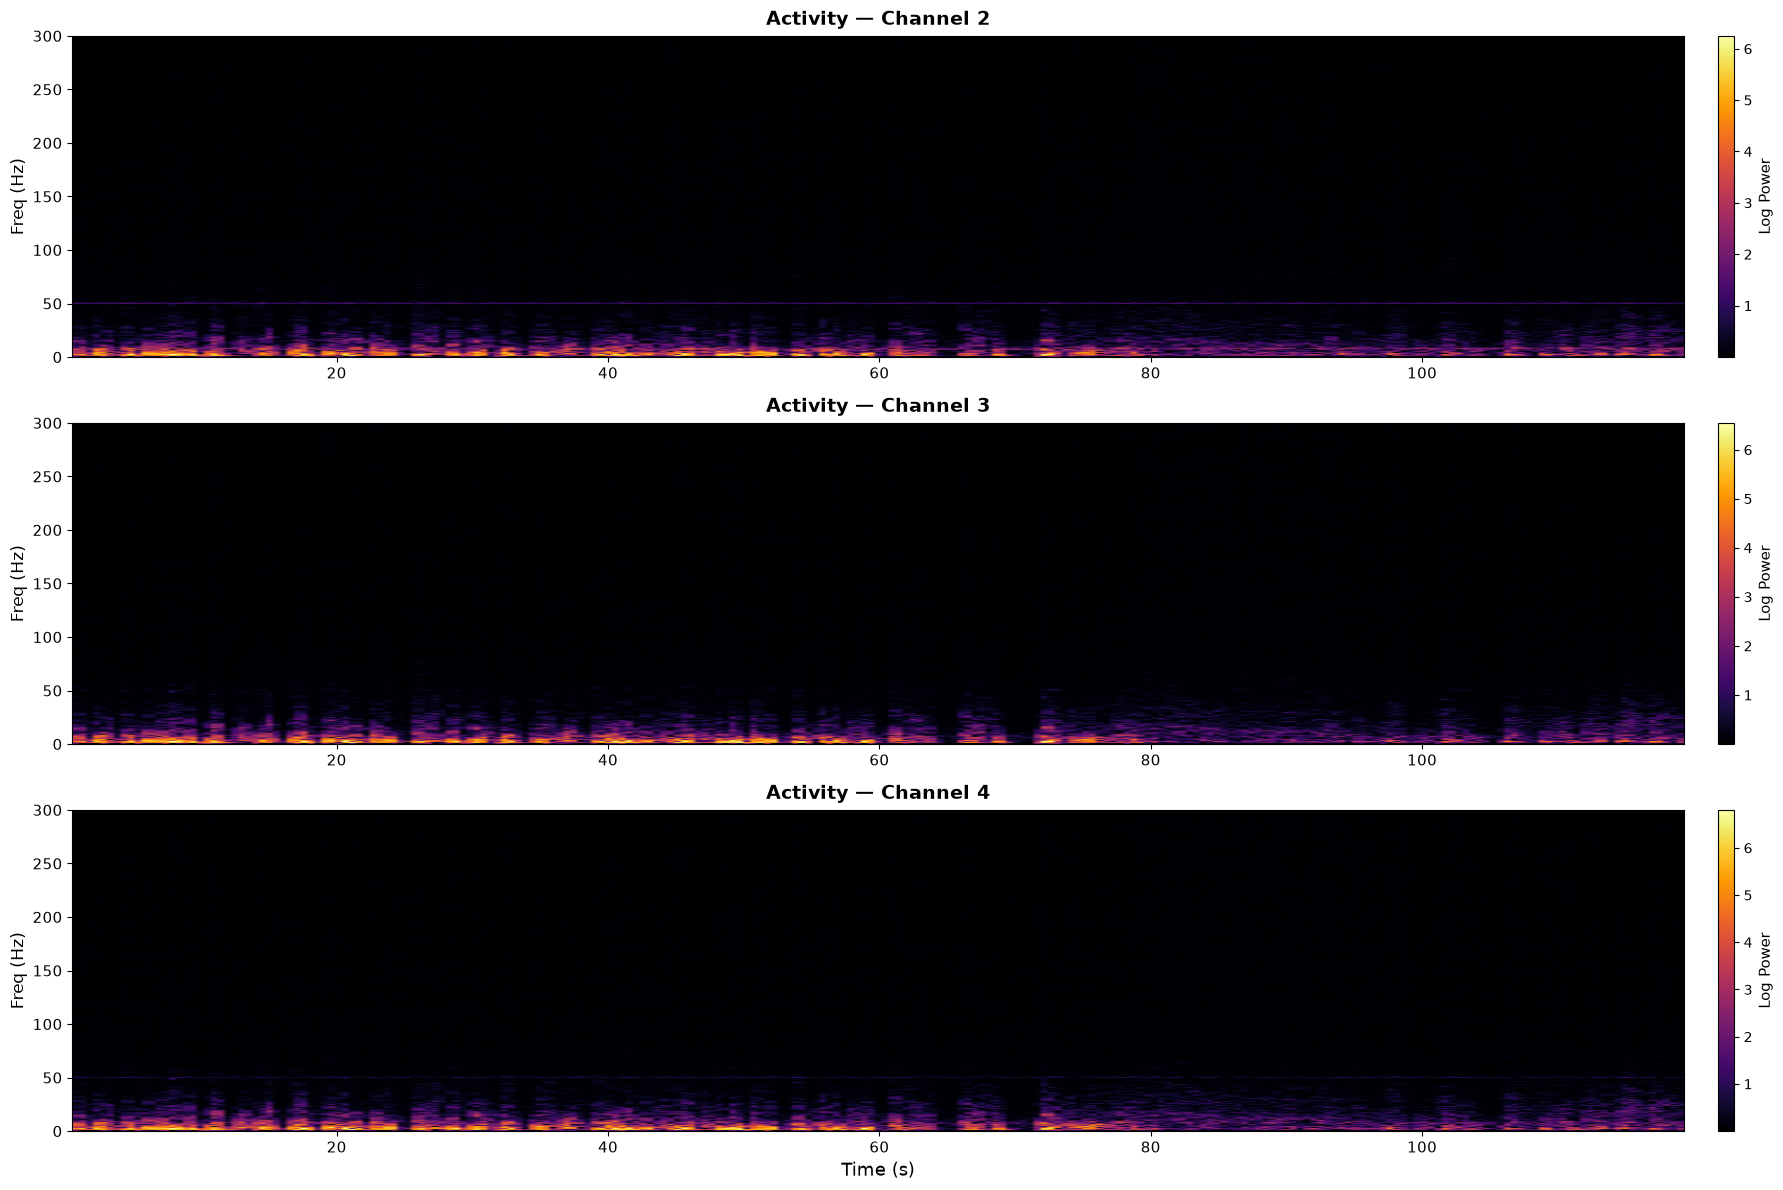

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram

SAMPLE_RATE = 1000
DURATION_SEC = 120
SAMPLES_2_MIN = DURATION_SEC * SAMPLE_RATE 
MAX_FREQ = 300  # limita spectrului vizibil

dataset_path = "Anestezie/M014_S001_SRCS3L_25,50,100_0004" 
all_files = [f for f in os.listdir(dataset_path) if f.endswith(".bin") and "-Ch" in f]

# Mapare numerica a fisierelor pentru a selecta exact canalul dorit
channel_files = {}
for f in all_files:
    try:
        ch_num = int(f.split("-Ch")[1].split(".")[0])
        channel_files[ch_num] = f
    except (IndexError, ValueError):
        continue

# Canalele pe care vrei sa le compari
channels_to_plot = [2, 3, 4]
num_channels = len(channels_to_plot)

# Inaltime adaptata dinamic: 4 unitati per canal pentru vizibilitate optima
plt.figure(figsize=(18, 4 * num_channels))

for i, ch in enumerate(channels_to_plot):
    ax = plt.subplot(num_channels, 1, i + 1)
    
    if ch not in channel_files:
        print(f"⚠️ Canalul {ch} nu a fost gasit.")
        ax.set_visible(False)
        continue

    file_path = os.path.join(dataset_path, channel_files[ch])
    ch_data = np.memmap(file_path, dtype=np.float32, mode='r')
    
    end_idx = min(SAMPLES_2_MIN, len(ch_data))
    filtered_signal = ch_data[:end_idx]

    f, t_axis, Sxx = spectrogram(filtered_signal, fs=SAMPLE_RATE, nperseg=1024, noverlap=512)
    Sxx_log = np.log1p(Sxx)
    
    img = ax.imshow(
        Sxx_log, 
        aspect='auto', 
        origin='lower', 
        extent=[t_axis[0], t_axis[-1], f[0], f[-1]], 
        cmap='inferno'
    )
    
    ax.set_ylim(0, MAX_FREQ) 
    ax.set_title(f"Activity — Channel {ch}", fontsize=14, fontweight='bold', pad=8)
    ax.set_ylabel("Freq (Hz)", fontsize=12)
    ax.tick_params(axis='both', which='major', labelsize=11)
    
    cbar = plt.colorbar(img, ax=ax, fraction=0.03, pad=0.02)
    cbar.ax.tick_params(labelsize=10)
    cbar.set_label("Log Power", fontsize=11)
    
    if i == num_channels - 1:
        ax.set_xlabel("Time (s)", fontsize=13)

plt.tight_layout()
plt.savefig("Fig_Canale_Inferno_150Hz.png", format='png', dpi=300)
plt.show()

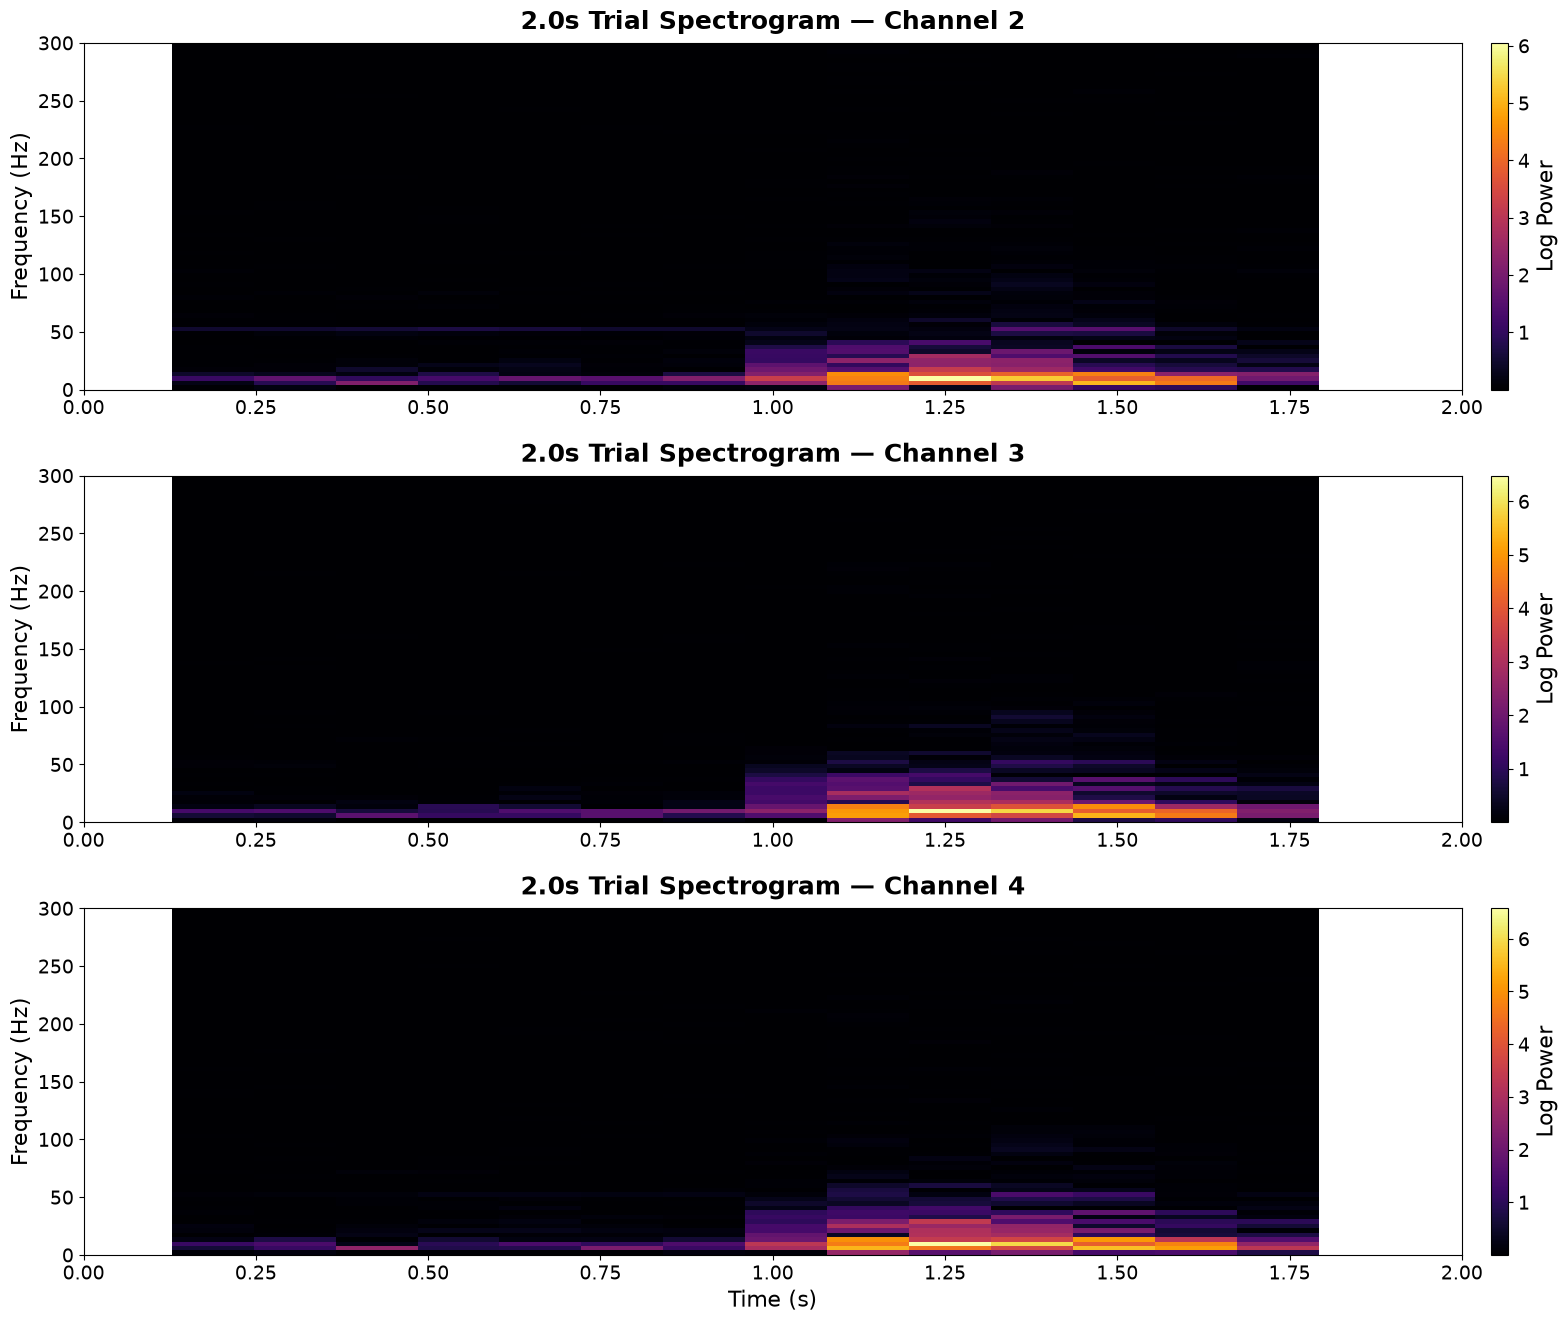

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram

plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'figure.titlesize': 20
})

SAMPLE_RATE = 1000
WINDOW_SEC = 2.0  # Durata de 2 secunde pentru fereastra de analiză
SAMPLES_WINDOW = int(WINDOW_SEC * SAMPLE_RATE) 
MAX_FREQ = 300  # Limita spectrului vizibil

dataset_path = "Anestezie/M014_S001_SRCS3L_25,50,100_0002" 
all_files = [f for f in os.listdir(dataset_path) if f.endswith(".bin") and "-Ch" in f]

channel_files = {}
for f in all_files:
    try:
        ch_num = int(f.split("-Ch")[1].split(".")[0])
        channel_files[ch_num] = f
    except (IndexError, ValueError):
        continue

channels_to_plot = [2, 3, 4]
num_channels = len(channels_to_plot)

plt.figure(figsize=(16, 4.5 * num_channels))

for i, ch in enumerate(channels_to_plot):
    ax = plt.subplot(num_channels, 1, i + 1)
    
    if ch not in channel_files:
        print(f"Canalul {ch} nu a fost gasit.")
        ax.set_visible(False)
        continue

    file_path = os.path.join(dataset_path, channel_files[ch])
    ch_data = np.memmap(file_path, dtype=np.float32, mode='r')
    
    # Luăm doar primele 2 secunde de semnal
    end_idx = min(SAMPLES_WINDOW, len(ch_data))
    signal_2s = ch_data[:end_idx]

    # Parametri STFT adaptați pentru fereastră scurtă (nperseg=256, noverlap=128, conform pipeline-ului tău)
    f, t_axis, Sxx = spectrogram(signal_2s, fs=SAMPLE_RATE, nperseg=256, noverlap=128)
    Sxx_log = np.log1p(Sxx)
    
    img = ax.imshow(
        Sxx_log, 
        aspect='auto', 
        origin='lower', 
        extent=[t_axis[0], t_axis[-1], f[0], f[-1]], 
        cmap='inferno'
    )
    
    ax.set_ylim(0, MAX_FREQ) 
    ax.set_xlim(0, WINDOW_SEC)
    ax.set_title(f"2.0s Trial Spectrogram — Channel {ch}", fontweight='bold', pad=10)
    ax.set_ylabel("Frequency (Hz)")
    
    cbar = plt.colorbar(img, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label("Log Power")
    
    if i == num_channels - 1:
        ax.set_xlabel("Time (s)")

plt.tight_layout()
plt.savefig("Fig_Spectrograma_2s.png", format='png', dpi=300)
plt.show()

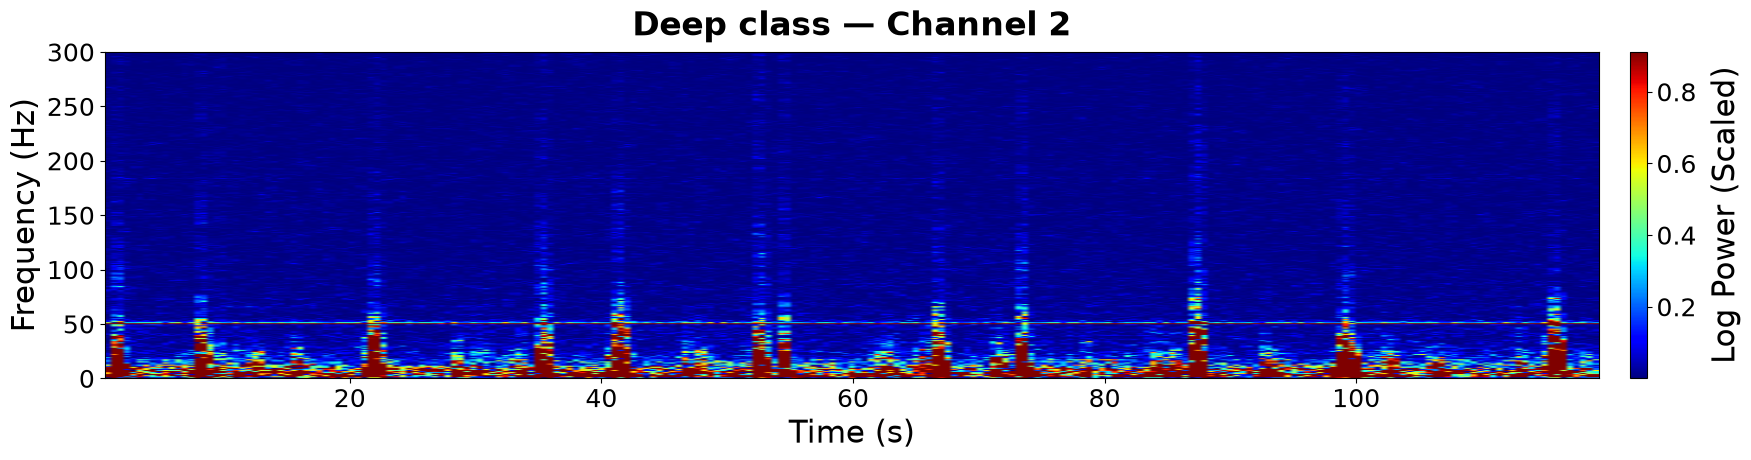

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram

# Setări globale de font mărite considerabil
plt.rcParams.update({
    'font.size': 20,
    'axes.titlesize': 24,
    'axes.labelsize': 22,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 18,
    'figure.titlesize': 26
})

SAMPLE_RATE = 1000
DURATION_SEC = 120
SAMPLES_2_MIN = DURATION_SEC * SAMPLE_RATE 
MAX_FREQ = 300  # limita spectrului vizibil

dataset_path = "Anestezie/M014_S001_SRCS3L_25,50,100_0002" 
all_files = [f for f in os.listdir(dataset_path) if f.endswith(".bin") and "-Ch" in f]

# Mapare numerica a fisierelor pentru a selecta exact canalul dorit
channel_files = {}
for f in all_files:
    try:
        ch_num = int(f.split("-Ch")[1].split(".")[0])
        channel_files[ch_num] = f
    except (IndexError, ValueError):
        continue

# Canalele pe care vrei sa le compari
channels_to_plot = [2]
num_channels = len(channels_to_plot)

# Inaltime adaptata dinamic pentru vizibilitate optima
plt.figure(figsize=(18, 5.0 * num_channels))

for i, ch in enumerate(channels_to_plot):
    ax = plt.subplot(num_channels, 1, i + 1)
    
    if ch not in channel_files:
        print(f"Canalul {ch} nu a fost gasit.")
        ax.set_visible(False)
        continue

    file_path = os.path.join(dataset_path, channel_files[ch])
    ch_data = np.memmap(file_path, dtype=np.float32, mode='r')
    
    end_idx = min(SAMPLES_2_MIN, len(ch_data))
    filtered_signal = ch_data[:end_idx]

    f, t_axis, Sxx = spectrogram(filtered_signal, fs=SAMPLE_RATE, nperseg=1024, noverlap=512)
    Sxx_log = np.log1p(Sxx)
    
    # Scalare/contrast pe baza de percentile (evita ca frecventele inalte sa fie negre/înecate)
    vmin = np.percentile(Sxx_log, 1)
    vmax = np.percentile(Sxx_log, 98)
    
    img = ax.imshow(
        Sxx_log, 
        aspect='auto', 
        origin='lower', 
        extent=[t_axis[0], t_axis[-1], f[0], f[-1]], 
        cmap='jet',
        vmin=vmin,
        vmax=vmax
    )
    
    ax.set_ylim(0, MAX_FREQ) 
    ax.set_title(f"Deep class — Channel {ch}", fontweight='bold', pad=12)
    ax.set_ylabel("Frequency (Hz)")
    
    cbar = plt.colorbar(img, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label("Log Power (Scaled)", labelpad=10)
    
    if i == num_channels - 1:
        ax.set_xlabel("Time (s)")

plt.tight_layout()
plt.savefig("Fig_Canale_Jet_Scaled.png", format='png', dpi=300)
plt.show()